# 1) Reading Dataset
---

Step 0: Importing necessary modules

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Step 1: Loading Factory dataset

In [40]:
import os
import kagglehub

# Download the dataset from Kaggle and load the CSV directly
path = kagglehub.dataset_download('canozensoy/industrial-iot-dataset-synthetic')
csv_path = os.path.join(path, 'factory_sensor_simulator_2040.csv')
df = pd.read_csv(csv_path)

Step 2: Displaying rows & understanding the data

In [41]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,NaN,NaN,NaN,NaN,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,NaN,NaN,NaN,NaN,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,NaN,NaN,NaN,NaN,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,NaN,NaN,NaN,NaN,2


In [42]:
df[['Last_Maintenance_Days_Ago', 'Maintenance_History_Count']]

,Last_Maintenance_Days_Ago,Maintenance_History_Count
0,153,4
1,136,5
2,258,1
3,43,4
4,346,4
...,...,...
499995,282,4
499996,208,4
499997,185,7
499998,274,3


Step 3: Statistics & other information about the data

In [43]:
df.describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,15156.000000,30340.000000,45624.000000,45214.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,452.422338,74.995513,119.917514,39.984794,499.760966,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,288.971269,10.035133,15.017048,9.989653,50.012057,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000,34.970000,52.680000,-0.160000,296.440000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,200.000000,68.250000,109.820000,33.200000,465.940000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,451.000000,74.950000,119.860000,40.030000,499.770000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,700.000000,81.682500,130.072500,46.750000,533.307500,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,1133.000000,114.320000,185.380000,80.790000,694.170000,11.000000


In [44]:
df[['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']].isna().sum()

Laser_Intensity           484844
Hydraulic_Pressure_bar    469660
Coolant_Flow_L_min        454376
Heat_Index                454786
dtype: int64

In [45]:
df.shape

(500000, 22)

In [46]:
df.columns # 22 initial columns

Index(['Machine_ID', 'Machine_Type', 'Installation_Year', 'Operational_Hours',
       'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct',
       'Coolant_Level_pct', 'Power_Consumption_kW',
       'Last_Maintenance_Days_Ago', 'Maintenance_History_Count',
       'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days',
       'Remaining_Useful_Life_days', 'Failure_Within_7_Days',
       'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min',
       'Heat_Index', 'AI_Override_Events'],
      dtype='str')

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  str    
 1   Machine_Type                500000 non-null  str    
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision           

# 2) Data Cleaning
---
#### Handeling:
- Duplicates
- Nulls

#### 1) Duplicate rows

A) Checking for duplicate rows

In [48]:
df.drop('Machine_ID', axis=1).duplicated().sum()

np.int64(0)

#### 2) Null Values

A) Checking for Nulls

In [49]:
df.isna().sum()

Machine_ID                         0
Machine_Type                       0
Installation_Year                  0
Operational_Hours                  0
Temperature_C                      0
Vibration_mms                      0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
Last_Maintenance_Days_Ago          0
Maintenance_History_Count          0
Failure_History_Count              0
AI_Supervision                     0
Error_Codes_Last_30_Days           0
Remaining_Useful_Life_days         0
Failure_Within_7_Days              0
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Coolant_Flow_L_min            454376
Heat_Index                    454786
AI_Override_Events                 0
dtype: int64

B) Checking normal distribution for columns with Nulls

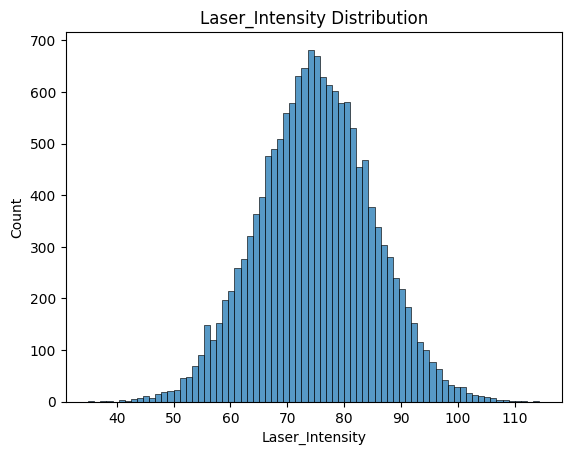

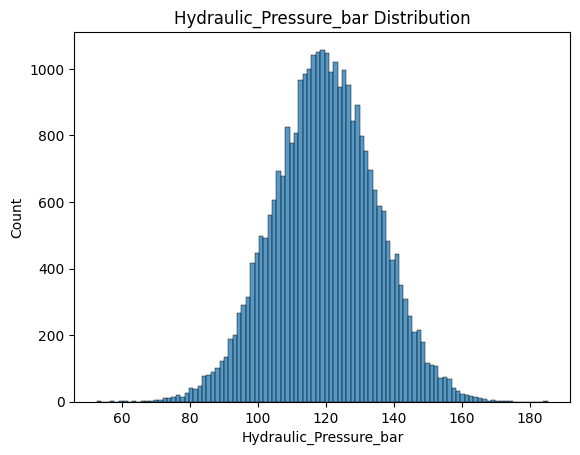

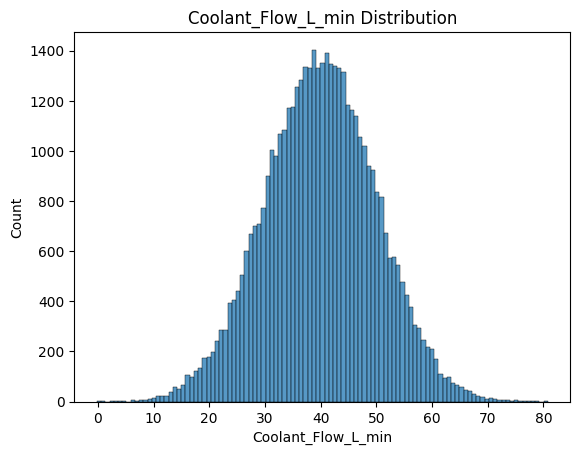

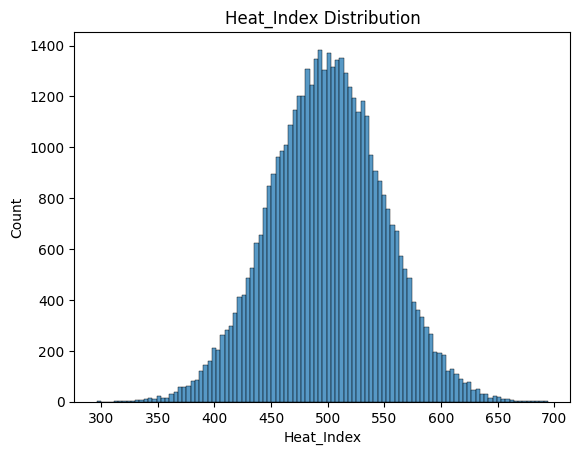

In [50]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    sns.histplot(df[col].dropna())
    plt.title(col + " Distribution")
    plt.show()
# Normal distribution for all columns.

C) Handeling Nulls

In [51]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    print(col, "has", (df[col] == 0).sum(), "rows with value 0")

Laser_Intensity has 0 rows with value 0
Hydraulic_Pressure_bar has 0 rows with value 0
Coolant_Flow_L_min has 0 rows with value 0
Heat_Index has 0 rows with value 0


In [52]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    df.fillna(0, inplace=True)

D) Assuring Null imputations done successfully

In [53]:
df.isna().sum()

Machine_ID                    0
Machine_Type                  0
Installation_Year             0
Operational_Hours             0
Temperature_C                 0
Vibration_mms                 0
Sound_dB                      0
Oil_Level_pct                 0
Coolant_Level_pct             0
Power_Consumption_kW          0
Last_Maintenance_Days_Ago     0
Maintenance_History_Count     0
Failure_History_Count         0
AI_Supervision                0
Error_Codes_Last_30_Days      0
Remaining_Useful_Life_days    0
Failure_Within_7_Days         0
Laser_Intensity               0
Hydraulic_Pressure_bar        0
Coolant_Flow_L_min            0
Heat_Index                    0
AI_Override_Events            0
dtype: int64

# 3) Data Analysis
---

1) Machine types with has the highest average operational hours

In [54]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,0.0,0.0,0.00,0.0,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,0.0,0.0,40.92,0.0,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,0.0,0.0,0.00,0.0,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,0.0,0.0,0.00,0.0,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,0.0,0.0,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,0.0,0.0,0.00,0.0,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,0.0,0.0,0.00,0.0,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,0.0,0.0,0.00,0.0,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,0.0,0.0,0.00,0.0,2


In [55]:
df.groupby('Machine_Type')['Operational_Hours'].mean().sort_values(ascending=False).to_frame()
# Palletizer has the highest average operational hours.

,Operational_Hours
Machine_Type,
Palletizer,50337.610931
Crane,50331.072582
Grinder,50326.816601
Pump,50323.834121
Furnace,50261.320689
CNC_Mill,50244.288303
CNC_Lathe,50214.587247
Valve_Controller,50189.671800
Pick_and_Place,50168.053450


2) Relation between Failure History VS Power Consumption (kW)

In [56]:
df.groupby('Failure_History_Count')['Power_Consumption_kW'].sum().sort_index().to_frame()

,Power_Consumption_kW
Failure_History_Count,
0,10100555.05
1,20272310.68
2,20332832.88
3,13560131.21
4,6732036.15
5,2720676.47
6,901349.54
7,262181.77
8,61632.80


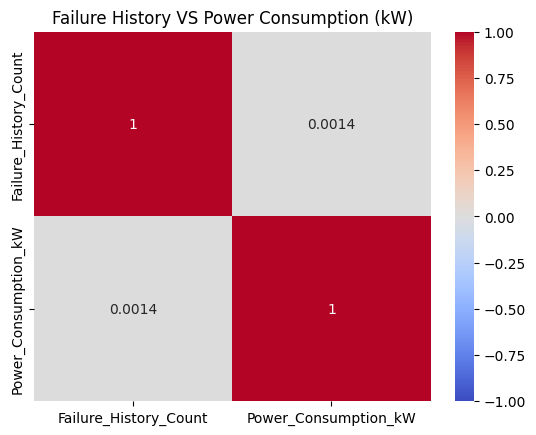

In [57]:
failure_power_cons_corr = df[['Failure_History_Count', 'Power_Consumption_kW']].corr()
sns.heatmap(failure_power_cons_corr, annot=True, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.title('Failure History VS Power Consumption (kW)')
plt.show()

# 5) Feature Engineering
---

# 6) Modles
---

In [58]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,0.0,0.0,0.00,0.0,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,0.0,0.0,40.92,0.0,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,0.0,0.0,0.00,0.0,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,0.0,0.0,0.00,0.0,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,0.0,0.0,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,0.0,0.0,0.00,0.0,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,0.0,0.0,0.00,0.0,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,0.0,0.0,0.00,0.0,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,0.0,0.0,0.00,0.0,2


In [59]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score 

## 5.1 Encoding and Mapping

In [60]:
from sklearn.preprocessing import LabelEncoder


def label_encode_column(series, known_values=None):
    values = series.astype(str)
    if known_values is None:
        known_values = sorted(values.dropna().unique())
    encoder = LabelEncoder()
    encoder.fit(list(known_values))
    return encoder.transform(values)


Machine_Types = [
    'Mixer', 'Industrial_Chiller', 'Pick_and_Place', 'Vision_System',
    'Shuttle_System', 'Labeler', 'Automated_Screwdriver', 'Shrink_Wrapper',
    'Laser_Cutter', 'CMM', 'CNC_Lathe', 'Dryer', 'Valve_Controller',
    'Furnace', 'Carton_Former', 'Hydraulic_Press', 'Compressor', 'AGV',
    'Robot_Arm', 'Conveyor_Belt', 'Forklift_Electric', 'Press_Brake',
    'Boiler', 'Vacuum_Packer', 'XRay_Inspector', 'Crane', '3D_Printer',
    'Palletizer', 'Grinder', 'CNC_Mill', 'Injection_Molder',
    'Heat_Exchanger', 'Pump'
]


df['Machine_Type'] = label_encode_column(df['Machine_Type'], Machine_Types)
df['AI_Supervision'] = label_encode_column(df['AI_Supervision'], ['True', 'False'])
df['Failure_Within_7_Days'] = label_encode_column(df['Failure_Within_7_Days'], ['True', 'False'])

In [61]:
df = df.drop(['Machine_ID'], axis=1)
df

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,21,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,...,5,1,3,162.0,0,0.0,0.0,0.00,0.0,2
1,17,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,...,2,1,4,147.0,0,0.0,0.0,40.92,0.0,2
2,23,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,...,1,1,6,0.0,1,0.0,0.0,0.00,0.0,2
3,31,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,...,1,0,4,161.0,0,0.0,0.0,0.00,0.0,0
4,28,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,...,2,0,1,765.0,0,0.0,0.0,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,29,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,282,...,3,0,0,820.0,0,0.0,0.0,0.00,0.0,0
499996,9,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,208,...,1,0,4,34.0,0,0.0,0.0,0.00,0.0,0
499997,4,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,185,...,2,0,4,815.0,0,0.0,0.0,0.00,0.0,0
499998,11,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,274,...,2,1,0,99.0,0,0.0,0.0,0.00,0.0,2


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prepare a clean modeling dataset
model_df = df.copy()
model_df = model_df.drop(columns=['Machine_ID'], errors='ignore')

for col in model_df.select_dtypes(include=['object', 'bool']).columns:
    if col != 'Remaining_Useful_Life_days':
        model_df[col] = label_encode_column(model_df[col])

X = model_df.drop(columns=['Remaining_Useful_Life_days'])
y = model_df['Remaining_Useful_Life_days']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print('R2 Score:', round(r2, 4))
print('RMSE:', round(rmse, 4))


R2 Score: 0.9433
RMSE: 68.7669


Feature Importances:
                  Feature  Importance
        Operational_Hours    0.972008
            Vibration_mms    0.003394
            Temperature_C    0.003056
                 Sound_dB    0.002402
     Power_Consumption_kW    0.002370
Last_Maintenance_Days_Ago    0.002279
            Oil_Level_pct    0.002191
        Coolant_Level_pct    0.002151
    Failure_Within_7_Days    0.001917
        Installation_Year    0.001803
             Machine_Type    0.001713
Maintenance_History_Count    0.001191
 Error_Codes_Last_30_Days    0.001002
    Failure_History_Count    0.000850
       AI_Override_Events    0.000449
               Heat_Index    0.000335
       Coolant_Flow_L_min    0.000322
   Hydraulic_Pressure_bar    0.000250
           AI_Supervision    0.000167
          Laser_Intensity    0.000150


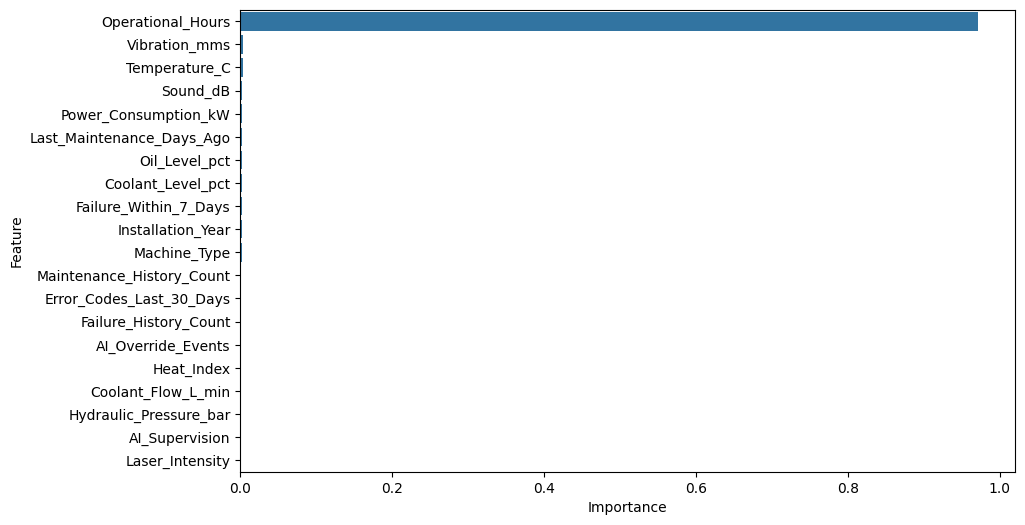

In [63]:
print('Feature Importances:')
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)

print(importance_df.to_string(index=False))

In [64]:
from sklearn.linear_model import LinearRegression


In [65]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [66]:
train_r2 = linear_model.score(X_train, y_train)
test_r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = pd.DataFrame({
    "Metric": ["Training R²", "Testing R²", "MSE", "RMSE"],
    "Value": [train_r2, test_r2, mse, rmse]
})

display(metrics)

print(f"The model explains approximately {test_r2 * 100:.2f}% of the variation in the test target.")


,Metric,Value
0,Training R²,0.971510
1,Testing R²,0.971437
2,MSE,2380.198649
3,RMSE,48.787280


The model explains approximately 97.14% of the variation in the test target.


<Axes: xlabel='Importance', ylabel='Feature'>

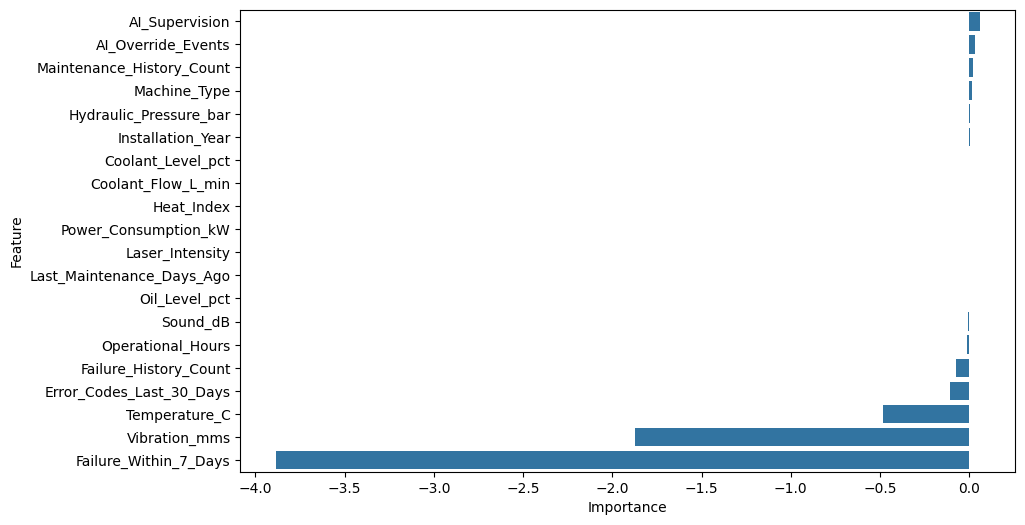

In [67]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': linear_model.coef_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)

In [68]:
from sklearn.ensemble import RandomForestRegressor


In [69]:

model = RandomForestRegressor(n_estimators=6, random_state=42)
model.fit(X_train, y_train)
y_predict = model.predict(X_test)



Accuracy: 0.9676311004693553


<Axes: xlabel='Importance', ylabel='Feature'>

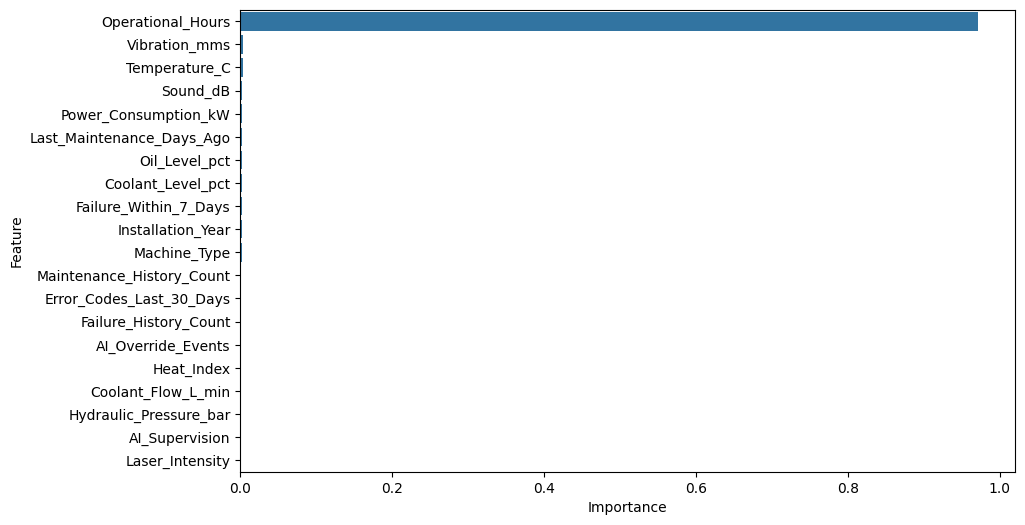

In [70]:
accuracy_score = model.score(X_test, y_test)
print("Accuracy:", accuracy_score)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)

In [71]:
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
except ModuleNotFoundError:
    import sys
    import subprocess

    print("TensorFlow is not installed. Installing it in the current environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])

    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    print("TensorFlow version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense,Dropout, BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
import numpy as np

TensorFlow version: 2.21.0


In [72]:
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='tanh'))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))


c:\Users\Ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
model.compile(optimizer='adam', # SGD, rmsprop , adagrad
              loss='sparse_categorical_crossentropy',     #binary_crossentropy,categorical_crossentropy
              metrics=['accuracy'])

In [ ]:
X_train_np = X_train.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_np = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train_np, y_train_np, epochs=3, batch_size=256, verbose=0)

test_loss, test_mae = model.evaluate(X_test_np, y_test_np, verbose=0)
print(f"Test MAE: {test_mae:.4f}")
test_pred = model.predict(X_test_np).reshape(-1)
test_r2 = r2_score(y_test_np.reshape(-1), test_pred)
print(f"Test R²: {test_r2:.4f}")

c:\Users\Ahmed\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MAE: 38.7521


NameError: name 'test_acc' is not defined

Analysis & Insights --> mo2men
Feature Engineering --> Mostafa Ali
Machine learning :
- logistic regression --> Bassam
- linear Regression --> Mostafa Ali
- decision tree --> Ahmed
- random forest --> Mostafa Hamed


1. User interface --> using AI (anyone) 
2. Deployment --> Ahmed
